In [ ]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'unsw-nb15' dataset.
Path to dataset files: /kaggle/input/unsw-nb15


In [ ]:
import kagglehub
import pandas as pd
import os
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix
from sklearn.metrics import roc_curve, auc
import seaborn as sns
import matplotlib.pyplot as plt




In [ ]:

path = kagglehub.dataset_download("mrwellsdavid/unsw-nb15")

print("مسار الملفات:", path)

print("\nالملفات المتوفرة:")
for root, dirs, files in os.walk(path):
    for file in files:
        print(os.path.join(root, file))


csv_file = os.path.join(path, "UNSW_NB15_training-set.csv")

df = pd.read_csv(csv_file, encoding='ISO-8859-1', low_memory=False)

print("تم تحميل الملف بنجاح")
print("شكل البيانات:", df.shape)
print(df.head())


Using Colab cache for faster access to the 'unsw-nb15' dataset.
مسار الملفات: /kaggle/input/unsw-nb15

الملفات المتوفرة:
/kaggle/input/unsw-nb15/UNSW_NB15_testing-set.csv
/kaggle/input/unsw-nb15/UNSW-NB15_1.csv
/kaggle/input/unsw-nb15/UNSW_NB15_training-set.csv
/kaggle/input/unsw-nb15/UNSW-NB15_LIST_EVENTS.csv
/kaggle/input/unsw-nb15/UNSW-NB15_4.csv
/kaggle/input/unsw-nb15/UNSW-NB15_3.csv
/kaggle/input/unsw-nb15/UNSW-NB15_2.csv
/kaggle/input/unsw-nb15/NUSW-NB15_features.csv
تم تحميل الملف بنجاح
شكل البيانات: (82332, 45)
   ï»¿id       dur proto service state  spkts  dpkts  sbytes  dbytes  \
0      1  0.000011   udp       -   INT      2      0     496       0   
1      2  0.000008   udp       -   INT      2      0    1762       0   
2      3  0.000005   udp       -   INT      2      0    1068       0   
3      4  0.000006   udp       -   INT      2      0     900       0   
4      5  0.000010   udp       -   INT      2      0    2126       0   

          rate  ...  ct_dst_sport_ltm  ct

In [ ]:
print(df.columns)


Index(['ï»¿id', 'dur', 'proto', 'service', 'state', 'spkts', 'dpkts', 'sbytes',
       'dbytes', 'rate', 'sttl', 'dttl', 'sload', 'dload', 'sloss', 'dloss',
       'sinpkt', 'dinpkt', 'sjit', 'djit', 'swin', 'stcpb', 'dtcpb', 'dwin',
       'tcprtt', 'synack', 'ackdat', 'smean', 'dmean', 'trans_depth',
       'response_body_len', 'ct_srv_src', 'ct_state_ttl', 'ct_dst_ltm',
       'ct_src_dport_ltm', 'ct_dst_sport_ltm', 'ct_dst_src_ltm',
       'is_ftp_login', 'ct_ftp_cmd', 'ct_flw_http_mthd', 'ct_src_ltm',
       'ct_srv_dst', 'is_sm_ips_ports', 'label'],
      dtype='object')


In [ ]:

target = "label"

X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]

id_cols = [col for col in X.columns if col.strip().lower().replace("ï»¿","") == "id"]
print("Detected id columns:", id_cols)

X_no_id = X.drop(columns=id_cols)


X_train_rf, X_val_rf, y_train_rf, y_val_rf = train_test_split(
    X_no_id, y, test_size=0.2, random_state=42, stratify=y
)

rf2 = RandomForestClassifier(
    n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'
)
rf2.fit(X_train_rf, y_train_rf)

rf2_importance_df = pd.DataFrame({
    "feature": X_no_id.columns,
    "importance": rf2.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_top10 = rf2_importance_df.head(10)
print("RF TOP 10 FEATURES:")
print(rf_top10)

# --- 4) SVM Feature Importance ---
from sklearn.preprocessing import StandardScaler
from sklearn.svm import LinearSVC
from sklearn.pipeline import make_pipeline

X_sub, _, y_sub, _ = train_test_split(
    X_no_id, y, train_size=0.25, random_state=42, stratify=y
)

X_train_s, X_val_s, y_train_s, y_val_s = train_test_split(
    X_sub, y_sub, test_size=0.2, random_state=42, stratify=y_sub
)

svm_pipe = make_pipeline(
    StandardScaler(),
    LinearSVC(C=0.5, max_iter=3000)
)

svm_pipe.fit(X_train_s, y_train_s)
svm_model = svm_pipe.named_steps['linearsvc']

coef = svm_model.coef_.ravel()
importances_svm = abs(coef)

svm_importance_df = pd.DataFrame({
    "feature": X_no_id.columns,
    "importance": importances_svm
}).sort_values(by="importance", ascending=False)

svm_top10 = svm_importance_df.head(10)
print("SVM TOP 10 FEATURES:")
print(svm_top10)


rf_features = list(rf_top10["feature"])
svm_features = list(svm_top10["feature"])

def evaluate_feature_set(feature_list, name):
    X_f = X_no_id[feature_list]
    Xtr, Xte, ytr, yte = train_test_split(
        X_f, y, test_size=0.2, random_state=42, stratify=y
    )
    clf = RandomForestClassifier(
        n_estimators=200, random_state=42, n_jobs=-1, class_weight='balanced'
    )
    clf.fit(Xtr, ytr)
    preds = clf.predict(Xte)
    acc = accuracy_score(yte, preds)
    print(f"{name} accuracy = {acc:.4f}")
    return acc

acc_rf = evaluate_feature_set(rf_features, "RandomForest top10")
acc_svm = evaluate_feature_set(svm_features, "SVM top10")


Detected id columns: ['ï»¿id']
RF TOP 10 FEATURES:
             feature  importance
32    ct_dst_src_ltm    0.072179
3             sbytes    0.057687
23             smean    0.054256
6               sttl    0.053890
8              sload    0.041523
37        ct_srv_dst    0.041517
0                dur    0.040806
28      ct_state_ttl    0.040752
31  ct_dst_sport_ltm    0.039226
5               rate    0.039082
SVM TOP 10 FEATURES:
            feature  importance
7              dttl    4.642091
9             dload    2.349496
4            dbytes    2.341611
149       proto_tcp    2.063827
32   ct_dst_src_ltm    1.845406
16             swin    1.747961
3            sbytes    1.555203
19             dwin    1.497660
11            dloss    1.476905
28     ct_state_ttl    1.353422
RandomForest top10 accuracy = 0.9668
SVM top10 accuracy = 0.9524


In [ ]:
# --- Block 1: Extract Top 10 Features from RandomForest ---

target = "label"

# One-hot encoding للـ categorical
X = pd.get_dummies(df.drop(columns=[target]), drop_first=True)
y = df[target]


id_cols = [col for col in X.columns if col.strip().lower().replace("ï»¿", "") == "id"]
X_no_id = X.drop(columns=id_cols)

# RandomForest Feature Selection
rf = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf.fit(X_no_id, y)

rf_importance_df = pd.DataFrame({
    "feature": X_no_id.columns,
    "importance": rf.feature_importances_
}).sort_values(by="importance", ascending=False)

rf_top10 = rf_importance_df.head(10)
print("Top 10 Features selected by Random Forest:")
print(rf_top10)


top10_features = list(rf_top10["feature"])


Top 10 Features selected by Random Forest:
           feature  importance
32  ct_dst_src_ltm    0.074639
3           sbytes    0.055986
6             sttl    0.052067
23           smean    0.047847
28    ct_state_ttl    0.047672
8            sload    0.043679
0              dur    0.042610
5             rate    0.042251
37      ct_srv_dst    0.040819
24           dmean    0.036369


In [ ]:
# --- Block 2: Prepare Dataset using Top 10 Features ---

X_top10 = X_no_id[top10_features]


X_top10 = X_top10.dropna()
y_clean = y.loc[X_top10.index]


X_top10 = X_top10.reset_index(drop=True)
y_clean = y_clean.reset_index(drop=True)

print(X_top10.shape, y_clean.shape)


(82332, 10) (82332,)


In [ ]:
# --- Block 3: Train / Test Split ---

from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_top10, y_clean,
    test_size=0.3,
    random_state=42,
    stratify=y_clean
)

print("Train shape:", X_train.shape)
print("Test shape:", X_test.shape)


Train shape: (57632, 10)
Test shape: (24700, 10)


In [ ]:
# --- Block 4: Train 5 Models and Compare Performance ---

from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import accuracy_score

models = {
    "Logistic Regression": LogisticRegression(max_iter=3000),
    "Decision Tree": DecisionTreeClassifier(),
    "Random Forest": RandomForestClassifier(n_estimators=200, random_state=42),
    "SVM": SVC(kernel="rbf"),
    "KNN": KNeighborsClassifier(n_neighbors=5)
}

results = {}

for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy = {acc:.4f}")

best_model_name = max(results, key=results.get)
best_model = models[best_model_name]

print("\n🔥 Best Model is:", best_model_name)


Logistic Regression Accuracy = 0.7522
Decision Tree Accuracy = 0.9596
Random Forest Accuracy = 0.9687
SVM Accuracy = 0.7459
KNN Accuracy = 0.8880

🔥 Best Model is: Random Forest


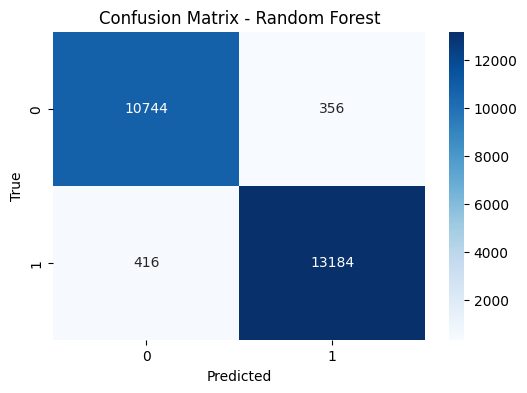

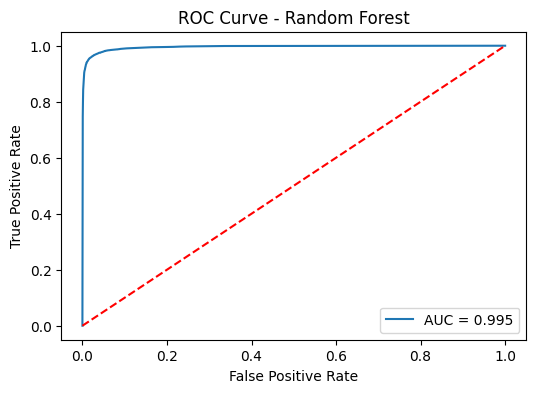

In [ ]:
# --- Block 5: Plots for the Best Model ---

from sklearn.metrics import confusion_matrix, roc_curve, auc
import matplotlib.pyplot as plt
import seaborn as sns

# Predictions
y_pred_best = best_model.predict(X_test)

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred_best)

plt.figure(figsize=(6,4))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title(f"Confusion Matrix - {best_model_name}")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

# ROC Curve (only works binary)
if len(y.unique()) == 2:
    y_prob = best_model.predict_proba(X_test)[:,1]
    fpr, tpr, thresholds = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)

    plt.figure(figsize=(6,4))
    plt.plot(fpr, tpr, label=f"AUC = {roc_auc:.3f}")
    plt.plot([0,1],[0,1],'r--')
    plt.title(f"ROC Curve - {best_model_name}")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.legend()
    plt.show()


Accuracy: 0.968744939271255
Precision: 0.9737075332348597
Recall: 0.9694117647058823
F1 Score: 0.9715549005158438


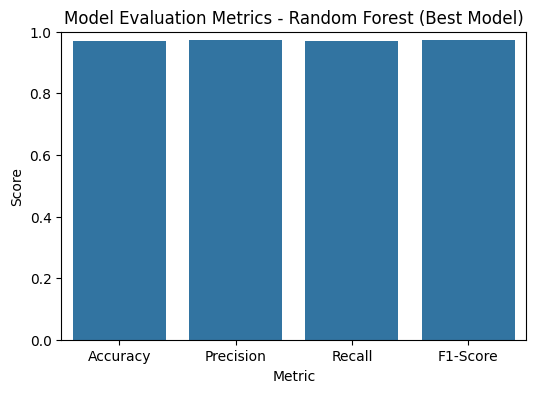

In [ ]:
# --- Accuracy / Precision / Recall / F1 ---

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

accuracy = accuracy_score(y_test, y_pred_best)
precision = precision_score(y_test, y_pred_best)
recall = recall_score(y_test, y_pred_best)
f1 = f1_score(y_test, y_pred_best)

print("Accuracy:", accuracy)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)


import seaborn as sns
import matplotlib.pyplot as plt

scores = {
    'Accuracy': accuracy,
    'Precision': precision,
    'Recall': recall,
    'F1-Score': f1
}

plt.figure(figsize=(6,4))
sns.barplot(x=list(scores.keys()), y=list(scores.values()))
plt.ylim(0, 1)
plt.title('Model Evaluation Metrics - Random Forest (Best Model)')
plt.ylabel('Score')
plt.xlabel('Metric')
plt.show()



Before: (82332, 44)
After: (48514, 44)


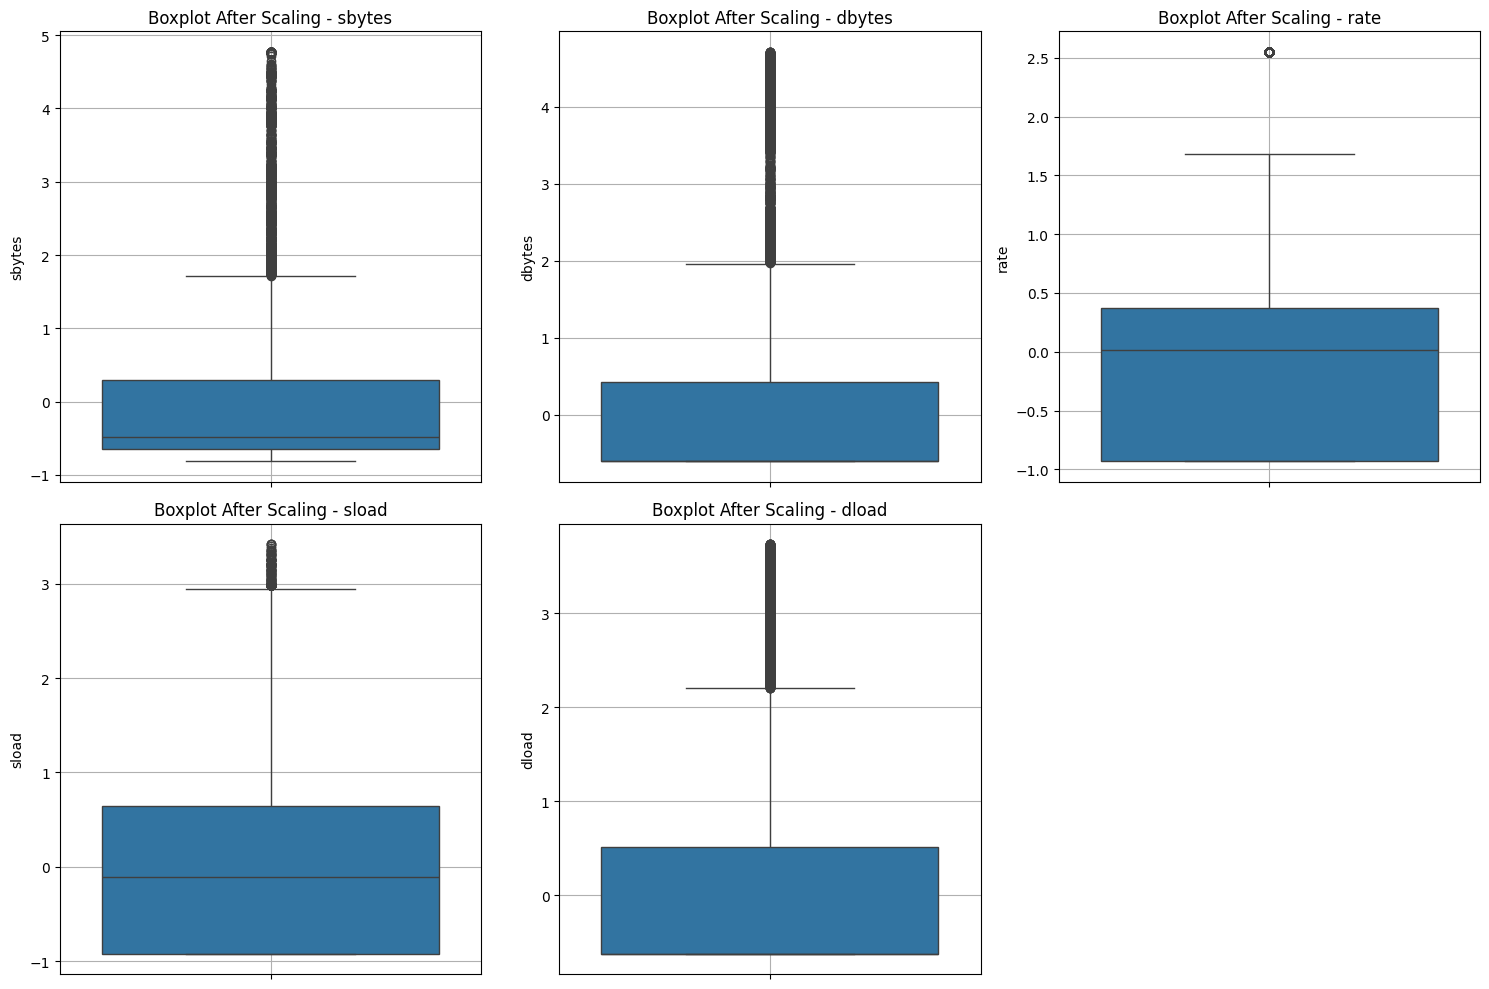

In [ ]:

cols = ['sbytes', 'dbytes', 'rate', 'sload', 'dload']


df_clean = df.copy()


for col in cols:
    Q1 = df_clean[col].quantile(0.25)
    Q3 = df_clean[col].quantile(0.75)
    IQR = Q3 - Q1
    low = Q1 - 1.5 * IQR
    high = Q3 + 1.5 * IQR
    df_clean = df_clean[(df_clean[col] >= low) & (df_clean[col] <= high)]

print("Before:", df.shape)
print("After:", df_clean.shape)


from sklearn.preprocessing import StandardScaler
import seaborn as sns
import matplotlib.pyplot as plt

scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean[cols])

df_scaled = pd.DataFrame(scaled_values, columns=cols)


plt.figure(figsize=(15, 10))

for i, col in enumerate(cols):
    plt.subplot(2, 3, i+1)
    sns.boxplot(y=df_scaled[col])
    plt.title(f"Boxplot After Scaling - {col}")
    plt.grid(True)

plt.tight_layout()
plt.show()


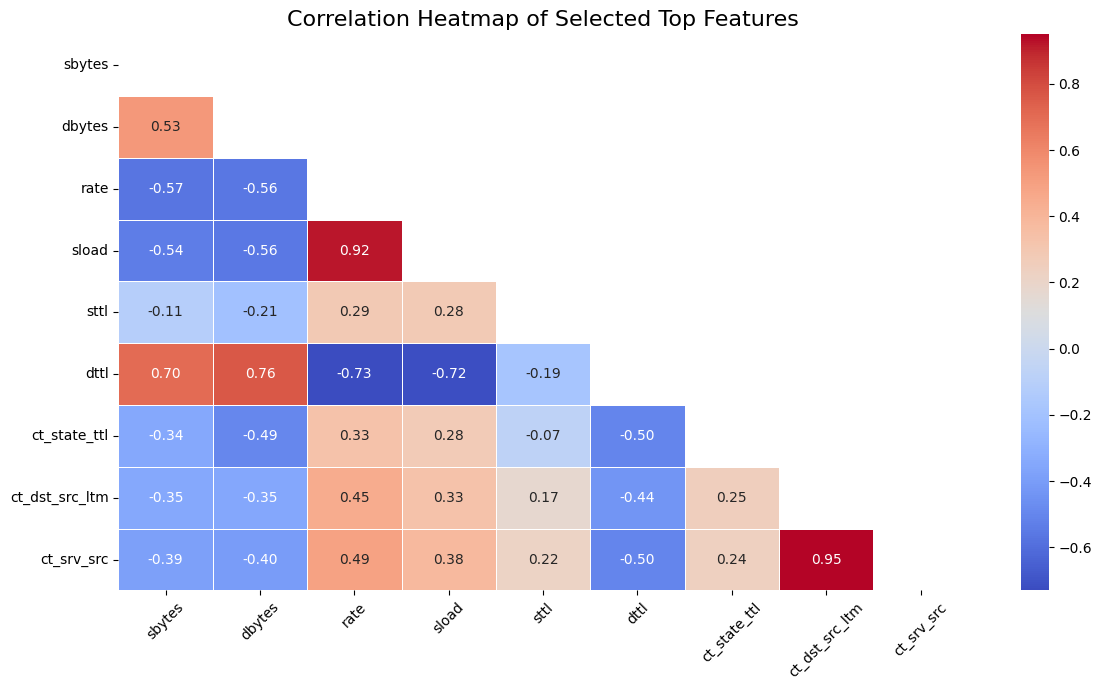

In [ ]:


import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt


top_features = ['sbytes', 'dbytes', 'rate', 'sload', 'sttl',
                'dttl', 'ct_state_ttl', 'ct_dst_src_ltm', 'ct_srv_src']

corr_data = df_clean[top_features]

corr_matrix = corr_data.corr()


mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

plt.figure(figsize=(12, 7))
sns.heatmap(
    corr_matrix,
    annot=True,
    cmap='coolwarm',
    fmt=".2f",
    linewidths=0.5,
    mask=mask
)
plt.title('Correlation Heatmap of Selected Top Features', fontsize=16)
plt.xticks(rotation=45)
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()
